In [4]:
import os

#Understancd the dataset
base_dir = r"E:\AI ML Projects\AI ML Course\Mini Projects\5. Brain Tumor Analysis\Tumour-20260416T172942Z-3-001\Tumour"

train_dir = base_dir + "\\train"
valid_dir = base_dir + "\\valid"
test_dir  = base_dir + "\\test"

categories = [folder for folder in os.listdir(train_dir) 
              if os.path.isdir(os.path.join(train_dir, folder))]

print("Categories (Tumor Types):", categories)
print("Number of classes:", len(categories))

Categories (Tumor Types): ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Number of classes: 4


In [5]:
import os
import matplotlib.pyplot as plt

# Base path
base_dir = r"E:\AI ML Projects\AI ML Course\Mini Projects\5. Brain Tumor Analysis\Tumour-20260416T172942Z-3-001\Tumour"

train_dir = os.path.join(base_dir, "train")
valid_dir = os.path.join(base_dir, "valid")
test_dir  = os.path.join(base_dir, "test")


# Function to count images per class
def count_images(directory):
    counts = {}
    
    for category in os.listdir(directory):
        path = os.path.join(directory, category)
        
        # ✅ Ignore files like _classes.csv
        if not os.path.isdir(path):
            continue
        
        # Count only image files (optional but safer)
        num_images = len([
            img for img in os.listdir(path)
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])
        
        counts[category] = num_images
    
    return counts
train_counts = count_images(train_dir)
valid_counts = count_images(valid_dir)
test_counts = count_images(test_dir)

print("Train Distribution:", train_counts)
print("Validation Distribution:", valid_counts)
print("Test Distribution:", test_counts)

Train Distribution: {'glioma': 564, 'meningioma': 358, 'no_tumor': 335, 'pituitary': 438}
Validation Distribution: {'glioma': 161, 'meningioma': 124, 'no_tumor': 99, 'pituitary': 118}
Test Distribution: {'glioma': 80, 'meningioma': 63, 'no_tumor': 49, 'pituitary': 54}


In [6]:
import os
from PIL import Image

#Check Image Resolution Consistency
def check_image_sizes(directory, sample_per_class=50):
    sizes = set()
    
    for category in os.listdir(directory):
        path = os.path.join(directory, category)
        
        # ✅ Skip non-folders
        if not os.path.isdir(path):
            continue
        
        images = os.listdir(path)[:sample_per_class]
        
        for img_name in images:
            img_path = os.path.join(path, img_name)
            
            try:
                with Image.open(img_path) as img:
                    sizes.add(img.size)  # (width, height)
            except:
                print("Error reading:", img_path)
    
    return sizes


train_sizes = check_image_sizes(train_dir)

print("Unique Image Sizes in Train Set:")
print(train_sizes)
print("Number of unique sizes:", len(train_sizes))

Unique Image Sizes in Train Set:
{(640, 640)}
Number of unique sizes: 1


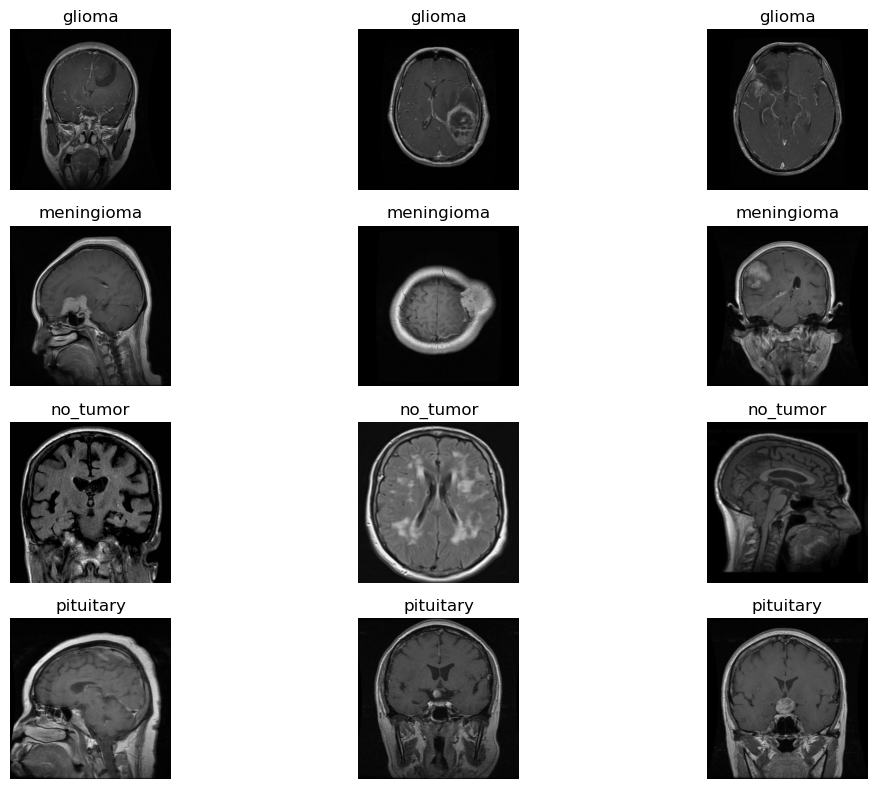

In [7]:
import os
import random
import matplotlib.pyplot as plt

#Image Distributions
def show_sample_images(directory, images_per_class=3):
    categories = [c for c in os.listdir(directory) 
                  if os.path.isdir(os.path.join(directory, c))]
    
    plt.figure(figsize=(12, 8))
    
    plot_index = 1
    
    for category in categories:
        path = os.path.join(directory, category)
        images = os.listdir(path)
        
        for i in range(images_per_class):
            img_name = random.choice(images)
            img_path = os.path.join(path, img_name)
            
            img = plt.imread(img_path)
            
            plt.subplot(len(categories), images_per_class, plot_index)
            plt.imshow(img, cmap='gray')
            plt.title(category)
            plt.axis('off')
            
            plot_index += 1
    
    plt.tight_layout()
    plt.show()


# Run it
show_sample_images(train_dir, images_per_class=3)

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Rescaling
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

#Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Load images with resizing
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),   # ✅ Resize
    batch_size=32,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1695 images belonging to 4 classes.
Found 502 images belonging to 4 classes.
Found 246 images belonging to 4 classes.


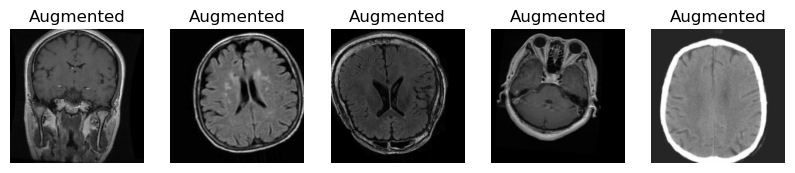

In [9]:
import matplotlib.pyplot as plt

# Visualizing the augmentation
aug_images, _ = next(train_generator)

plt.figure(figsize=(10,5))
# Augmented
for i in range(5):
    plt.subplot(2,5,i+6)
    plt.imshow(aug_images[i])
    plt.title("Augmented")
    plt.axis('off')

plt.show()

D:\Reneta_AI_ML\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,861,188 (37.62 MB)

 Trainable params: 9,860,228 (37.61 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.4720 - loss: 4.9577 - val_accuracy: 0.2351 - val_loss: 13.1381
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.4584 - loss: 1.6674 - val_accuracy: 0.2351 - val_loss: 4.8492
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.4224 - loss: 1.3609 - val_accuracy: 0.2351 - val_loss: 4.6052
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.3823 - loss: 1.2829 - val_accuracy: 0.1932 - val_loss: 3.5960
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.4484 - loss: 1.3182 - val_accuracy: 0.4641 - val_loss: 1.4035
Epoch 6/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.4165 - loss: 1.2711 - val_accuracy: 0.0976 - val_loss: 12.2725
Epoch 7/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.4366 - loss: 1.2715 - val_accuracy: 0.3108 - val_loss: 3.2767
Epoch 8/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.4336 - loss: 1.3375 - val_accuracy: 0.5219 - val_los

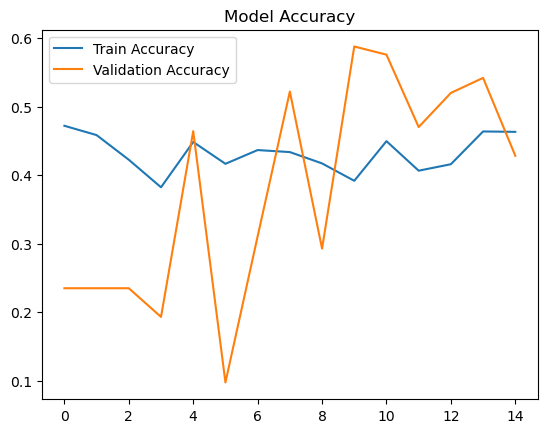

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
# CNN Model

model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Block 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Block 4
model.add(Conv2D(256, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Flatten
model.add(Flatten())

# Dense layers
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

# Output layer (4 classes)
model.add(Dense(4, activation='softmax'))

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

# 🚀 Train
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=15
)

# 📈 Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

In [11]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

#ResNet50
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')
valid_gen = valid_datagen.flow_from_directory(valid_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
output = Dense(4, activation='softmax')(x)

resnet_model = Model(inputs=base_model.input, outputs=output)

resnet_model.compile(optimizer=Adam(0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

resnet_history = resnet_model.fit(train_gen, validation_data=valid_gen, epochs=10)

Found 1695 images belonging to 4 classes.
Found 502 images belonging to 4 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.5263 - loss: 1.2128 - val_accuracy: 0.7112 - val_loss: 0.7852
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.6826 - loss: 0.8218 - val_accuracy: 0.7629 - val_loss: 0.7721
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.7646 - loss: 0.6560 - val_accuracy: 0.7809 - val_loss: 0.6359
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.7788 - loss: 0.6013 - val_accuracy: 0.7988 - val_loss: 0.6277
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.7858 - loss: 0.5868 - val_accuracy: 0.7649 - val_loss: 0.5762
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.7953 - loss: 0.5890 - val_accuracy: 0.7869 - val_loss: 0.5643
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.8083 - loss: 0.5015 - val_accuracy: 0.7888 - 

In [12]:
from tensorflow.keras.applications import EfficientNetB0

#EfficientNetB0
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')
valid_gen = valid_datagen.flow_from_directory(valid_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')

base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
output = Dense(4, activation='softmax')(x)

efficient_model = Model(inputs=base_model.input, outputs=output)

efficient_model.compile(optimizer=Adam(0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

efficient_history = efficient_model.fit(train_gen, validation_data=valid_gen, epochs=10)

Found 1695 images belonging to 4 classes.
Found 502 images belonging to 4 classes.
Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 46s 750ms/step - accuracy: 0.3109 - loss: 1.5362 - val_accuracy: 0.2351 - val_loss: 1.4140
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 38s 713ms/step - accuracy: 0.2826 - loss: 1.4382 - val_accuracy: 0.2470 - val_loss: 1.4737
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 704ms/step - accuracy: 0.3009 - loss: 1.3931 - val_accuracy: 0.2351 - val_loss: 1.3949
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 39s 728ms/step - accuracy: 0.3086 - loss: 1.3867 - val_accuracy: 0.2351 - val_loss: 1.3922
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 38s 722ms/step - accuracy: 0.3027 - loss: 1.3864 - val_accuracy: 0.3207 - val_loss: 1.3848
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 705ms/step - accuracy: 0.3074 - loss: 1.3960 - val_accuracy: 0.3207 - val_loss: 1.4536
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 39s 732ms/step - accuracy: 0.3032 - loss: 1.3933 - val_accuracy: 0.2351 - val_loss: 1.3839
Epoch 8/10
53/

In [14]:
from tensorflow.keras.applications import MobileNetV2

#MobileNetV2
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')
valid_gen = valid_datagen.flow_from_directory(valid_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
output = Dense(4, activation='softmax')(x)

mobilenet_model = Model(inputs=base_model.input, outputs=output)

mobilenet_model.compile(optimizer=Adam(0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

mobilenet_history = mobilenet_model.fit(train_gen, validation_data=valid_gen, epochs=10)

Found 1695 images belonging to 4 classes.
Found 502 images belonging to 4 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 606ms/step - accuracy: 0.8106 - loss: 0.5726 - val_accuracy: 0.8825 - val_loss: 0.3002
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 598ms/step - accuracy: 0.9711 - loss: 0.0891 - val_accuracy: 0.9084 - val_loss: 0.2643
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 590ms/step - accuracy: 0.9971 - loss: 0.0219 - val_accuracy: 0.9223 - val_loss: 0.2272
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 610ms/step - accuracy: 1.0000 - loss: 0.0080 - val_accuracy: 0.9143 - val_loss: 0.2420
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 601ms/step - accuracy: 1.0000 - loss: 0.0041 - val_accuracy: 0.9124 - val_loss: 0.2541
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 586ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 0.9203 - val_loss: 0.2406
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 597ms/step - accuracy: 1.0000 - loss: 0.0024 - val_a

In [15]:
from tensorflow.keras.applications import InceptionV3

#InceptionV3
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')
valid_gen = valid_datagen.flow_from_directory(valid_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')

base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
output = Dense(4, activation='softmax')(x)

inception_model = Model(inputs=base_model.input, outputs=output)

inception_model.compile(optimizer=Adam(0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

inception_history = inception_model.fit(train_gen, validation_data=valid_gen, epochs=10)

Found 1695 images belonging to 4 classes.
Found 502 images belonging to 4 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 46s 781ms/step - accuracy: 0.7422 - loss: 0.7459 - val_accuracy: 0.8526 - val_loss: 0.4154
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 40s 752ms/step - accuracy: 0.9274 - loss: 0.2064 - val_accuracy: 0.8685 - val_loss: 0.4065
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 39s 734ms/step - accuracy: 0.9705 - loss: 0.0991 - val_accuracy: 0.8964 - val_loss: 0.2975
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 39s 744ms/step - accuracy: 0.9965 - loss: 0.0401 - val_accuracy: 0.8924 - val_loss: 0.3259
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 39s 737ms/step - accuracy: 0.9994 - loss: 0.0178 - val_accuracy: 0.9004 - val_loss: 0.3102
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 40s 752ms/step - accuracy: 0.9994 - loss: 0.0112 - val_accuracy: 0.9004 - val_loss: 0.3104
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 39s 741ms/step - accuracy: 0.9994 - loss: 0.0080 - va

In [16]:
#Finetuning

from tensorflow.keras.optimizers import Adam

# Unfreeze last 20 layers
for layer in resnet_model.layers[-20:]:
    layer.trainable = True

# Recompile
resnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train again
resnet_fine_history = resnet_model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=5
)

Epoch 1/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.6956 - loss: 1.4993 - val_accuracy: 0.4801 - val_loss: 1.3322
Epoch 2/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.8425 - loss: 0.4359 - val_accuracy: 0.2032 - val_loss: 5.2461
Epoch 3/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.8885 - loss: 0.3245 - val_accuracy: 0.1972 - val_loss: 6.0191
Epoch 4/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9150 - loss: 0.2574 - val_accuracy: 0.2450 - val_loss: 3.7935
Epoch 5/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9180 - loss: 0.2279 - val_accuracy: 0.4741 - val_loss: 1.8578


In [17]:
for layer in efficient_model.layers[-20:]:
    layer.trainable = True

# Recompile
efficient_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train again
efficient_fine_history = efficient_model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=5
)

Epoch 1/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 54s 871ms/step - accuracy: 0.3139 - loss: 1.4315 - val_accuracy: 0.3207 - val_loss: 1.4114
Epoch 2/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 45s 855ms/step - accuracy: 0.3150 - loss: 1.3922 - val_accuracy: 0.3207 - val_loss: 1.4442
Epoch 3/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 47s 894ms/step - accuracy: 0.3392 - loss: 1.3654 - val_accuracy: 0.3207 - val_loss: 1.4407
Epoch 4/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 46s 868ms/step - accuracy: 0.3640 - loss: 1.3475 - val_accuracy: 0.3207 - val_loss: 1.4433
Epoch 5/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 47s 881ms/step - accuracy: 0.3746 - loss: 1.3401 - val_accuracy: 0.3207 - val_loss: 1.3886


In [18]:
# Unfreeze last 20 layers
for layer in mobilenet_model.layers[-20:]:
    layer.trainable = True

# Recompile
mobilenet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train again
mobilenet_fine_history = mobilenet_model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=5
)

# Unfreeze last 20 layers
for layer in inception_model.layers[-20:]:
    layer.trainable = True

# Recompile
inception_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train again
inception_fine_history = inception_model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=5
)

Epoch 1/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 44s 725ms/step - accuracy: 0.9257 - loss: 0.1947 - val_accuracy: 0.8367 - val_loss: 0.6329
Epoch 2/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 679ms/step - accuracy: 0.9841 - loss: 0.0476 - val_accuracy: 0.8227 - val_loss: 0.7064
Epoch 3/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 663ms/step - accuracy: 0.9941 - loss: 0.0277 - val_accuracy: 0.8267 - val_loss: 0.6429
Epoch 4/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 682ms/step - accuracy: 1.0000 - loss: 0.0141 - val_accuracy: 0.8526 - val_loss: 0.5669
Epoch 5/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 699ms/step - accuracy: 1.0000 - loss: 0.0095 - val_accuracy: 0.8506 - val_loss: 0.5531
Epoch 1/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 49s 793ms/step - accuracy: 1.0000 - loss: 0.0153 - val_accuracy: 0.8765 - val_loss: 0.4172
Epoch 2/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 41s 769ms/step - accuracy: 1.0000 - loss: 0.0089 - val_accuracy: 0.8904 - val_loss: 0.3555
Epoch 3/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 41s 783ms/step - accuracy: 1.0000 - loss: 0.0082 - val_accuracy: 0.

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5287 - loss: 2.1511  

53/53 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.6029 - loss: 1.3089 - val_accuracy: 0.5717 - val_loss: 0.9874
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7281 - loss: 0.7266  

53/53 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.7162 - loss: 0.7293 - val_accuracy: 0.7629 - val_loss: 0.5849
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.7215 - loss: 0.7095 - val_accuracy: 0.7490 - val_loss: 0.6155
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.7469 - loss: 0.6555 - val_accuracy: 0.7869 - val_loss: 0.6010
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.7634 - loss: 0.6306 - val_accuracy: 0.7470 - val_loss: 0.6583


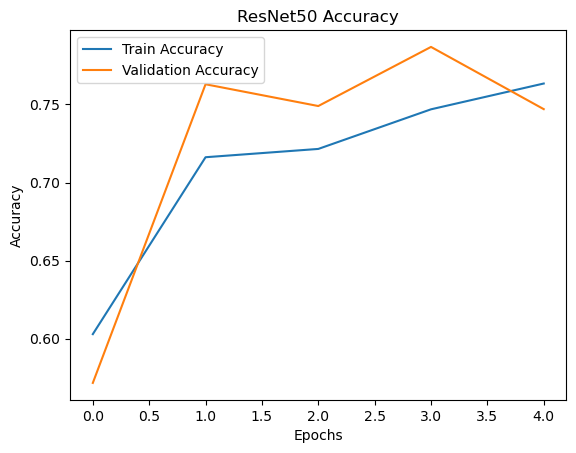

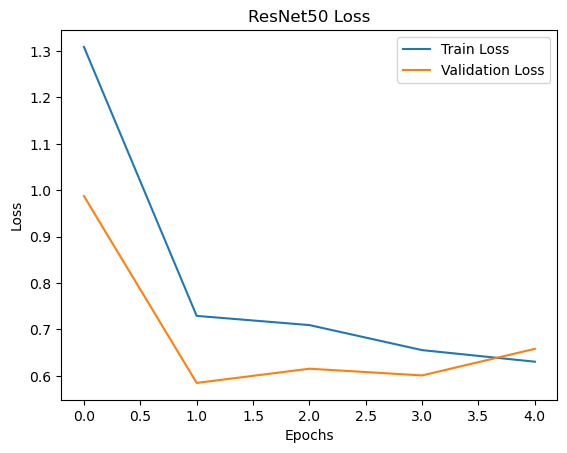

In [19]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

#Resnet Model
# 🔹 Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint_resnet = ModelCheckpoint(
    'best_resnet.h5',
    monitor='val_loss',
    save_best_only=True
)

# 🔹 Compile (if not already compiled)
resnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 🔹 Train
resnet_history = resnet_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20,
    callbacks=[early_stop, checkpoint_resnet]
)

# 🔹 Plot Accuracy
plt.figure()
plt.plot(resnet_history.history['accuracy'], label='Train Accuracy')
plt.plot(resnet_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('ResNet50 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 🔹 Plot Loss
plt.figure()
plt.plot(resnet_history.history['loss'], label='Train Loss')
plt.plot(resnet_history.history['val_loss'], label='Validation Loss')
plt.title('ResNet50 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 832ms/step - accuracy: 0.2939 - loss: 1.4658 

53/53 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.3097 - loss: 1.4259 - val_accuracy: 0.3247 - val_loss: 1.3470
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.3416 - loss: 1.3571 - val_accuracy: 0.3227 - val_loss: 1.3666
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.3416 - loss: 1.3489 - val_accuracy: 0.3406 - val_loss: 1.3865
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 865ms/step - accuracy: 0.3487 - loss: 1.3383 

53/53 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.3634 - loss: 1.3284 - val_accuracy: 0.4163 - val_loss: 1.2886
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.4006 - loss: 1.3098 - val_accuracy: 0.4641 - val_loss: 1.3212
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 857ms/step - accuracy: 0.3959 - loss: 1.3172 

53/53 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.4035 - loss: 1.3088 - val_accuracy: 0.4064 - val_loss: 1.2876
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 810ms/step - accuracy: 0.4014 - loss: 1.3141 

53/53 ━━━━━━━━━━━━━━━━━━━━ 51s 962ms/step - accuracy: 0.4094 - loss: 1.2995 - val_accuracy: 0.4263 - val_loss: 1.2584
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 51s 959ms/step - accuracy: 0.4224 - loss: 1.2825 - val_accuracy: 0.5159 - val_loss: 1.2685
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.4260 - loss: 1.2865 - val_accuracy: 0.4741 - val_loss: 1.2766
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 811ms/step - accuracy: 0.3951 - loss: 1.2944 

53/53 ━━━━━━━━━━━━━━━━━━━━ 51s 971ms/step - accuracy: 0.4130 - loss: 1.2852 - val_accuracy: 0.4482 - val_loss: 1.2459
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 50s 935ms/step - accuracy: 0.4071 - loss: 1.2945 - val_accuracy: 0.2928 - val_loss: 1.3493
Epoch 12/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 48s 913ms/step - accuracy: 0.4260 - loss: 1.2809 - val_accuracy: 0.3765 - val_loss: 1.3206
Epoch 13/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 49s 919ms/step - accuracy: 0.4525 - loss: 1.2509 - val_accuracy: 0.4044 - val_loss: 1.3487


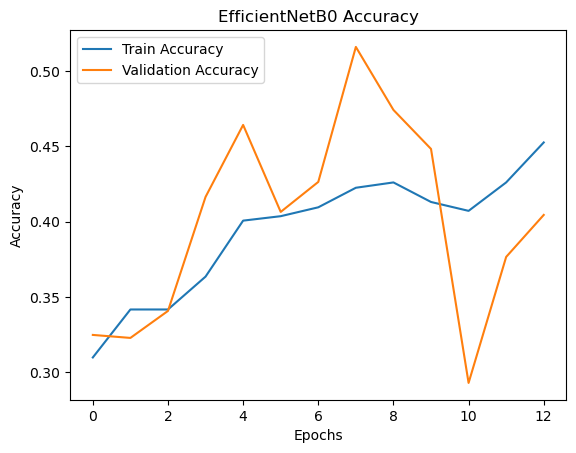

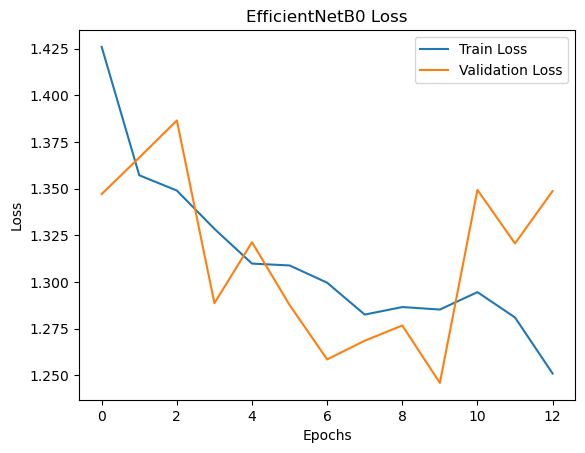

In [20]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# 🔹 Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint_eff = ModelCheckpoint(
    'best_efficientnet.h5',
    monitor='val_loss',
    save_best_only=True
)

# 🔹 Compile (if not already compiled)
efficient_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 🔹 Train
efficient_history = efficient_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20,
    callbacks=[early_stop, checkpoint_eff]
)

# 🔹 Plot Accuracy
plt.figure()
plt.plot(efficient_history.history['accuracy'], label='Train Accuracy')
plt.plot(efficient_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('EfficientNetB0 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 🔹 Plot Loss
plt.figure()
plt.plot(efficient_history.history['loss'], label='Train Loss')
plt.plot(efficient_history.history['val_loss'], label='Validation Loss')
plt.title('EfficientNetB0 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 710ms/step - accuracy: 0.8651 - loss: 0.4756 

53/53 ━━━━━━━━━━━━━━━━━━━━ 50s 862ms/step - accuracy: 0.8602 - loss: 0.4674 - val_accuracy: 0.7769 - val_loss: 1.0373
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - accuracy: 0.9344 - loss: 0.1814 

53/53 ━━━━━━━━━━━━━━━━━━━━ 43s 803ms/step - accuracy: 0.9322 - loss: 0.1746 - val_accuracy: 0.8685 - val_loss: 0.6201
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 43s 803ms/step - accuracy: 0.9445 - loss: 0.1415 - val_accuracy: 0.8625 - val_loss: 0.7513
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 42s 797ms/step - accuracy: 0.9652 - loss: 0.0987 - val_accuracy: 0.8665 - val_loss: 0.8032
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 680ms/step - accuracy: 0.9759 - loss: 0.0601 

53/53 ━━━━━━━━━━━━━━━━━━━━ 43s 809ms/step - accuracy: 0.9646 - loss: 0.0861 - val_accuracy: 0.8765 - val_loss: 0.5923
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 676ms/step - accuracy: 0.9664 - loss: 0.0905 

53/53 ━━━━━━━━━━━━━━━━━━━━ 42s 797ms/step - accuracy: 0.9711 - loss: 0.0798 - val_accuracy: 0.8924 - val_loss: 0.5376
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 43s 813ms/step - accuracy: 0.9805 - loss: 0.0547 - val_accuracy: 0.8884 - val_loss: 0.7942
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 43s 811ms/step - accuracy: 0.9735 - loss: 0.0819 - val_accuracy: 0.9004 - val_loss: 0.5565
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 697ms/step - accuracy: 0.9761 - loss: 0.0613 

53/53 ━━━━━━━━━━━━━━━━━━━━ 44s 822ms/step - accuracy: 0.9752 - loss: 0.0689 - val_accuracy: 0.9084 - val_loss: 0.4832
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 45s 847ms/step - accuracy: 0.9829 - loss: 0.0433 - val_accuracy: 0.8944 - val_loss: 0.6613
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 44s 832ms/step - accuracy: 0.9864 - loss: 0.0370 - val_accuracy: 0.9223 - val_loss: 0.5286
Epoch 12/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 45s 852ms/step - accuracy: 0.9882 - loss: 0.0358 - val_accuracy: 0.9084 - val_loss: 0.6783


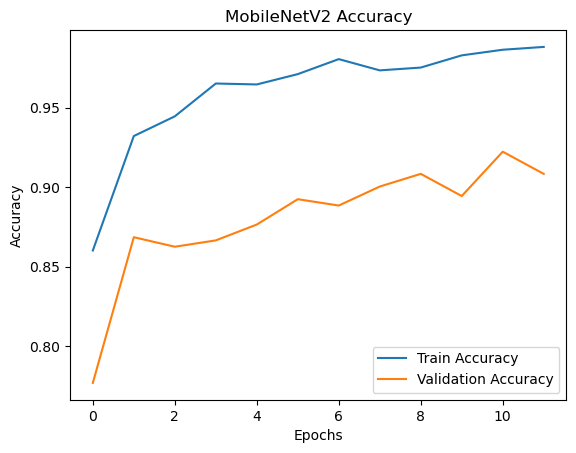

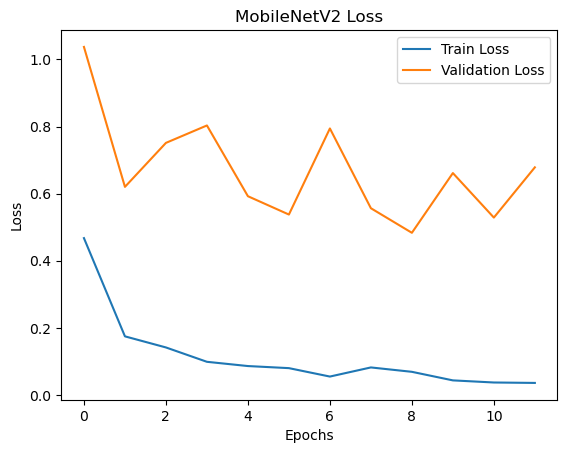

In [21]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# 🔹 Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint_mob = ModelCheckpoint(
    'best_mobilenet.h5',
    monitor='val_loss',
    save_best_only=True
)

# 🔹 Compile (if not already compiled)
mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 🔹 Train
mobilenet_history = mobilenet_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20,
    callbacks=[early_stop, checkpoint_mob]
)

# 🔹 Plot Accuracy
plt.figure()
plt.plot(mobilenet_history.history['accuracy'], label='Train Accuracy')
plt.plot(mobilenet_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 🔹 Plot Loss
plt.figure()
plt.plot(mobilenet_history.history['loss'], label='Train Loss')
plt.plot(mobilenet_history.history['val_loss'], label='Validation Loss')
plt.title('MobileNetV2 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 743ms/step - accuracy: 0.8787 - loss: 0.3524 

53/53 ━━━━━━━━━━━━━━━━━━━━ 57s 956ms/step - accuracy: 0.8914 - loss: 0.3336 - val_accuracy: 0.8765 - val_loss: 0.3720
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 751ms/step - accuracy: 0.9410 - loss: 0.1853 

53/53 ━━━━━━━━━━━━━━━━━━━━ 49s 918ms/step - accuracy: 0.9327 - loss: 0.1949 - val_accuracy: 0.8984 - val_loss: 0.2916
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 817ms/step - accuracy: 0.9351 - loss: 0.1745 

53/53 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.9375 - loss: 0.1737 - val_accuracy: 0.9163 - val_loss: 0.2882
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 50s 940ms/step - accuracy: 0.9534 - loss: 0.1387 - val_accuracy: 0.9124 - val_loss: 0.3118
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 49s 927ms/step - accuracy: 0.9587 - loss: 0.1196 - val_accuracy: 0.9044 - val_loss: 0.3387
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 51s 964ms/step - accuracy: 0.9670 - loss: 0.0908 - val_accuracy: 0.9104 - val_loss: 0.3406


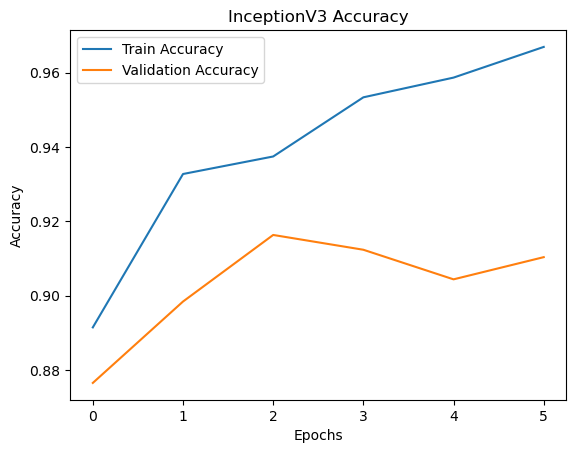

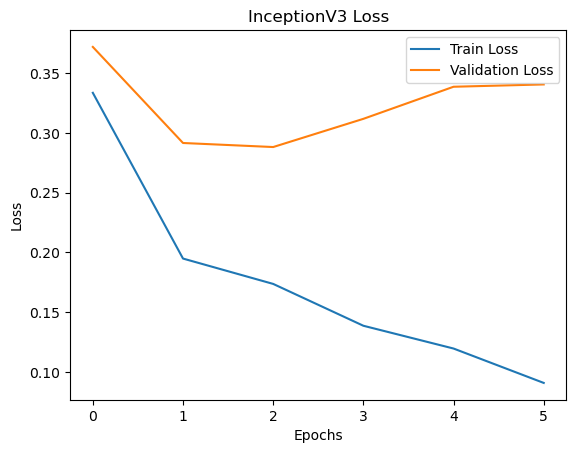

In [22]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# 🔹 Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint_inc = ModelCheckpoint(
    'best_inception.h5',
    monitor='val_loss',
    save_best_only=True
)

# 🔹 Compile (if not already compiled)
inception_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 🔹 Train
inception_history = inception_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20,
    callbacks=[early_stop, checkpoint_inc]
)

# 🔹 Plot Accuracy
plt.figure()
plt.plot(inception_history.history['accuracy'], label='Train Accuracy')
plt.plot(inception_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('InceptionV3 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 🔹 Plot Loss
plt.figure()
plt.plot(inception_history.history['loss'], label='Train Loss')
plt.plot(inception_history.history['val_loss'], label='Validation Loss')
plt.title('InceptionV3 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5021 - loss: 1.1087  

53/53 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.5109 - loss: 1.1443 - val_accuracy: 0.5398 - val_loss: 0.9674
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.4201 - loss: 1.2179 - val_accuracy: 0.4681 - val_loss: 1.0373
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.4206 - loss: 1.1973 - val_accuracy: 0.5239 - val_loss: 1.4515
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.4726 - loss: 1.1590 - val_accuracy: 0.2988 - val_loss: 6.9034


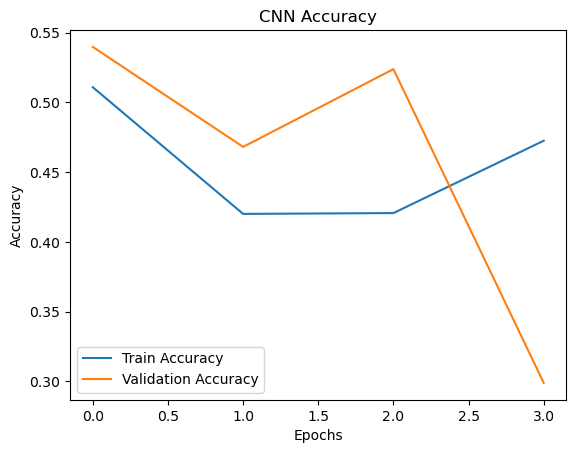

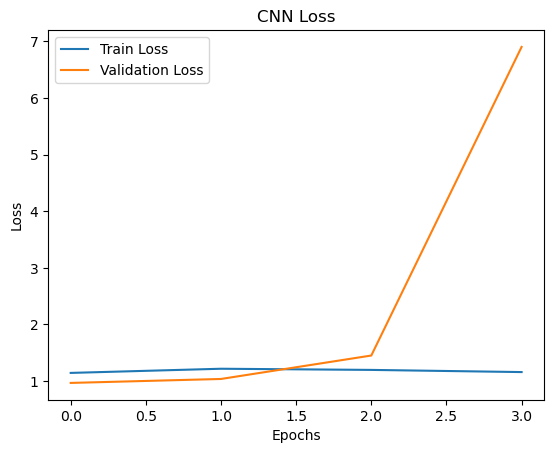

In [24]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

#CNN
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint_cnn = ModelCheckpoint(
    'best_cnn.h5',
    monitor='val_loss',
    save_best_only=True
)

# 🔹 Train CNN
cnn_history = model.fit(   # or cnn_model.fit(...)
    train_generator,
    validation_data=valid_generator,
    epochs=20,
    callbacks=[early_stop, checkpoint_cnn]
)

# 🔹 Plot Accuracy
plt.figure()
plt.plot(cnn_history.history['accuracy'], label='Train Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 🔹 Plot Loss
plt.figure()
plt.plot(cnn_history.history['loss'], label='Train Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


🔍 Evaluating CNN...

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 416ms/step
Classification Report:
              precision    recall  f1-score   support

      glioma       0.98      0.75      0.85        80
  meningioma       0.00      0.00      0.00        63
    no_tumor       0.71      0.10      0.18        49
   pituitary       0.30      1.00      0.47        54

    accuracy                           0.48       246
   macro avg       0.50      0.46      0.37       246
weighted avg       0.53      0.48      0.41       246



D:\Reneta_AI_ML\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Reneta_AI_ML\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Reneta_AI_ML\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


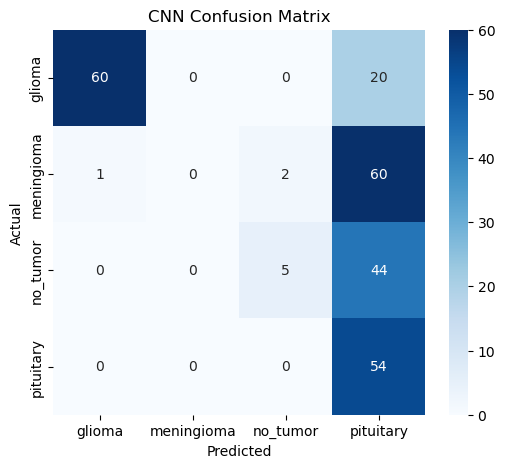


🔍 Evaluating ResNet50...

8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step   
Classification Report:
              precision    recall  f1-score   support

      glioma       0.71      0.85      0.77        80
  meningioma       0.67      0.35      0.46        63
    no_tumor       0.69      0.84      0.76        49
   pituitary       0.90      0.96      0.93        54

    accuracy                           0.74       246
   macro avg       0.74      0.75      0.73       246
weighted avg       0.74      0.74      0.72       246



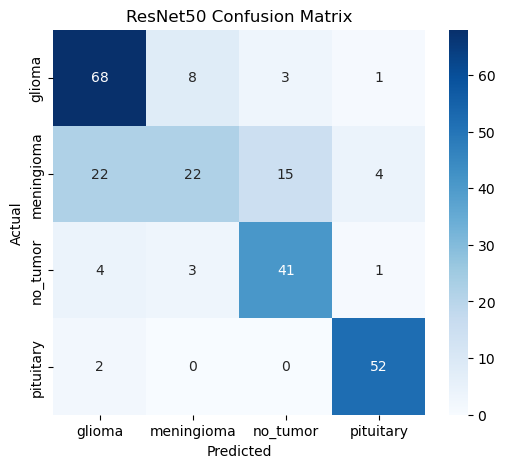


🔍 Evaluating EfficientNetB0...



8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 658ms/step
Classification Report:
              precision    recall  f1-score   support

      glioma       0.46      1.00      0.63        80
  meningioma       0.00      0.00      0.00        63
    no_tumor       0.73      0.45      0.56        49
   pituitary       0.41      0.31      0.36        54

    accuracy                           0.48       246
   macro avg       0.40      0.44      0.39       246
weighted avg       0.39      0.48      0.39       246



D:\Reneta_AI_ML\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Reneta_AI_ML\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Reneta_AI_ML\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


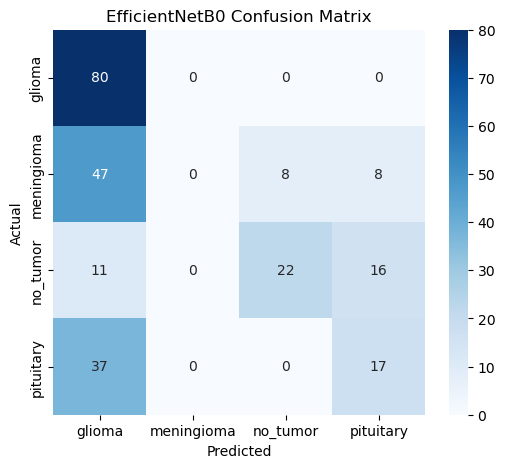


🔍 Evaluating MobileNetV2...



8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 466ms/step
Classification Report:
              precision    recall  f1-score   support

      glioma       0.89      1.00      0.94        80
  meningioma       0.98      0.75      0.85        63
    no_tumor       0.96      0.88      0.91        49
   pituitary       0.86      1.00      0.92        54

    accuracy                           0.91       246
   macro avg       0.92      0.91      0.91       246
weighted avg       0.92      0.91      0.91       246



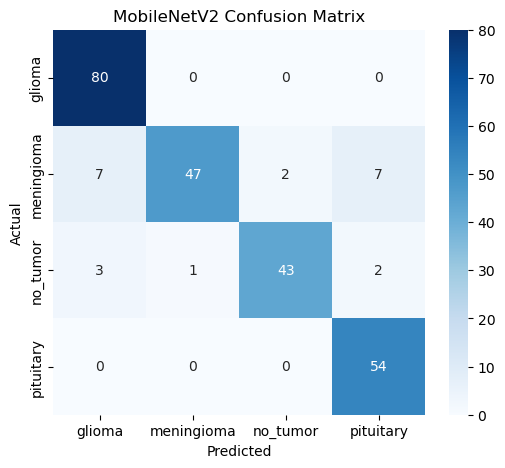


🔍 Evaluating InceptionV3...

8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 700ms/step
Classification Report:
              precision    recall  f1-score   support

      glioma       0.90      0.99      0.94        80
  meningioma       0.90      0.84      0.87        63
    no_tumor       1.00      0.80      0.89        49
   pituitary       0.90      1.00      0.95        54

    accuracy                           0.91       246
   macro avg       0.92      0.91      0.91       246
weighted avg       0.92      0.91      0.91       246



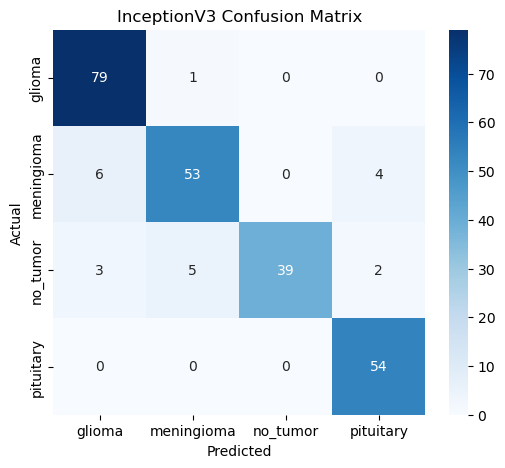

In [25]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, model_name):
    print(f"\n🔍 Evaluating {model_name}...\n")
    
    preds = model.predict(test_generator)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_generator.classes

    # Classification Report
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=test_generator.class_indices.keys(),
                yticklabels=test_generator.class_indices.keys())

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

evaluate_model(model, "CNN")
evaluate_model(resnet_model, "ResNet50")
evaluate_model(efficient_model, "EfficientNetB0")
evaluate_model(mobilenet_model, "MobileNetV2")
evaluate_model(inception_model, "InceptionV3")

In [26]:
results = []

from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

def evaluate_and_store(model, model_name):
    preds = model.predict(test_generator)
    y_pred = preds.argmax(axis=1)
    y_true = test_generator.classes

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "F1 Score": f1
    })

evaluate_and_store(model, "CNN")
evaluate_and_store(resnet_model, "ResNet50")
evaluate_and_store(efficient_model, "EfficientNetB0")
evaluate_and_store(mobilenet_model, "MobileNetV2")
evaluate_and_store(inception_model, "InceptionV3")

df = pd.DataFrame(results)
print(df)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 234ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step   
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 588ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 459ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 532ms/step
            Model  Accuracy  F1 Score
0             CNN  0.483740  0.414525
1        ResNet50  0.743902  0.723739
2  EfficientNetB0  0.483740  0.393551
3     MobileNetV2  0.910569  0.907811
4     InceptionV3  0.914634  0.912868


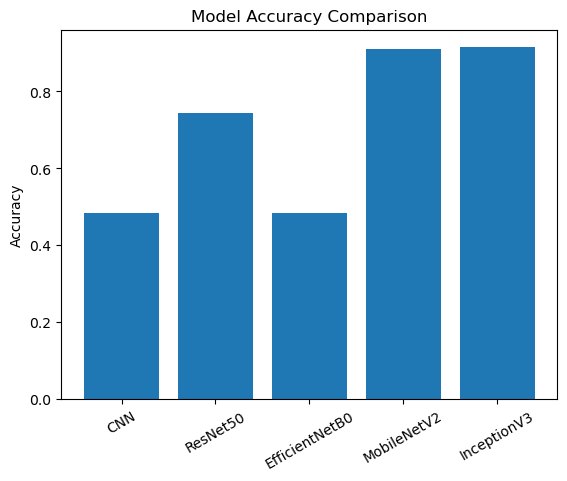

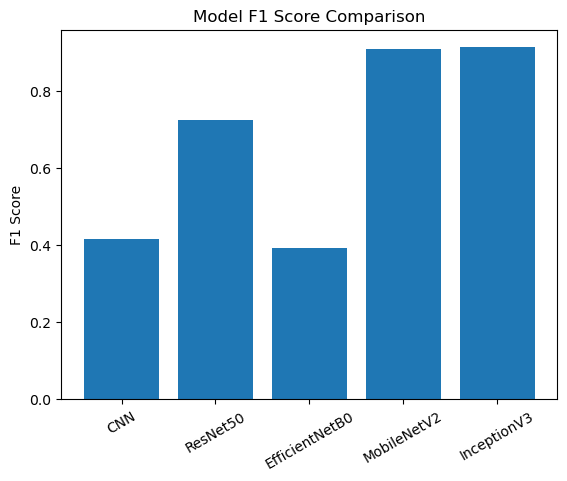

In [27]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df["Model"], df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

plt.figure()
plt.bar(df["Model"], df["F1 Score"])
plt.title("Model F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xticks(rotation=30)
plt.show()